# GRAFICAS

## comparación entre lo estimado  y la comparacion con metricas entre lab quimico y lo estimado

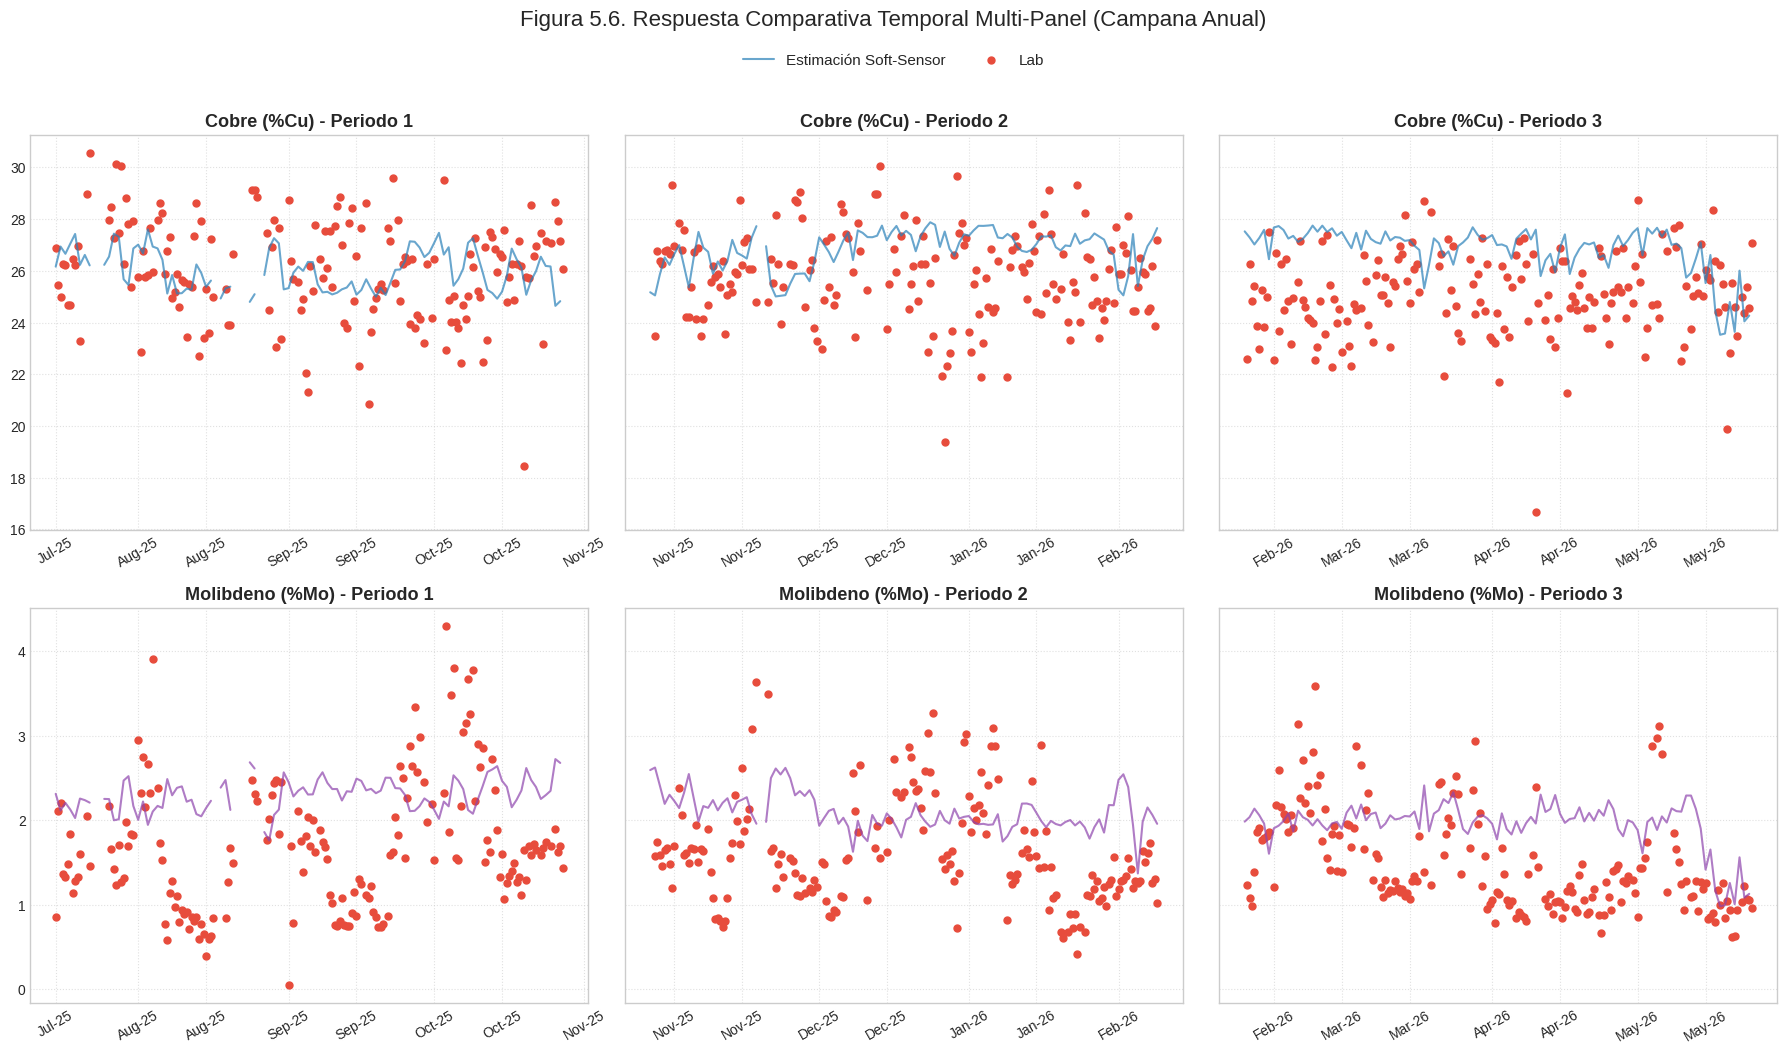

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Carga de datos
df_pred = pd.read_csv('data/final/soft_sensor_continuous_predictions.csv')
df_pred['timestamp'] = pd.to_datetime(df_pred['timestamp'])
df_audit = pd.read_csv('data/final/soft_sensor_audit_results.csv')
df_audit['timestamp'] = pd.to_datetime(df_audit['timestamp'])

# 2. Definición de periodos (Dividir el tiempo total en tres tercios)
total_start = df_pred['timestamp'].min()
total_end = df_pred['timestamp'].max()
period_length = (total_end - total_start) / 3

periods = [
    (total_start, total_start + period_length),
    (total_start + period_length, total_start + 2 * period_length),
    (total_start + 2 * period_length, total_end)
]

# 3. Configuración de figuras (2 filas: Cobre y Molibdeno | 3 columnas: periodos)
# Usamos 'sharey=row' para que el Cobre y el Molibdeno mantengan su propia escala vertical
elements = [('pCu', 'pCu_Est', 'Cobre (%Cu)', '#2980b9'), 
            ('pMo', 'pMo_Est', 'Molibdeno (%Mo)', '#8e44ad')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')

for row, (col_lab, col_est, title, color) in enumerate(elements):
    for col, (start, end) in enumerate(periods):
        ax = axes[row, col]
        
        # Filtrar datos de predicción (resample diario para legibilidad)
        df_pred_sub = df_pred[(df_pred['timestamp'] >= start) & (df_pred['timestamp'] <= end)]
        df_pred_daily = df_pred_sub.set_index('timestamp')[[col_est]].resample('D').mean()
        
        # Filtrar datos de auditoría
        df_lab_sub = df_audit[(df_audit['timestamp'] >= start) & (df_audit['timestamp'] <= end)]
        
        # Graficar
        ax.plot(df_pred_daily.index, df_pred_daily[col_est], color=color, alpha=0.7, linewidth=1.5, label='Estimación Soft-Sensor')
        ax.scatter(df_lab_sub['timestamp'], df_lab_sub[col_lab], color='#e74c3c', s=25, label='Lab')
        
        ax.set_title(f"{title} - Periodo {col + 1}", weight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        plt.setp(ax.get_xticklabels(), rotation=30)
        ax.grid(True, linestyle=':', alpha=0.6)

# Ajustes finales y leyenda
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Figura 5.6. Respuesta Comparativa Temporal Multi-Panel (Campana Anual)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('figura_56_comparativa_anual_detallada.png', dpi=300)
plt.show()

## comparacion directa entre lo estimado y lab quimico

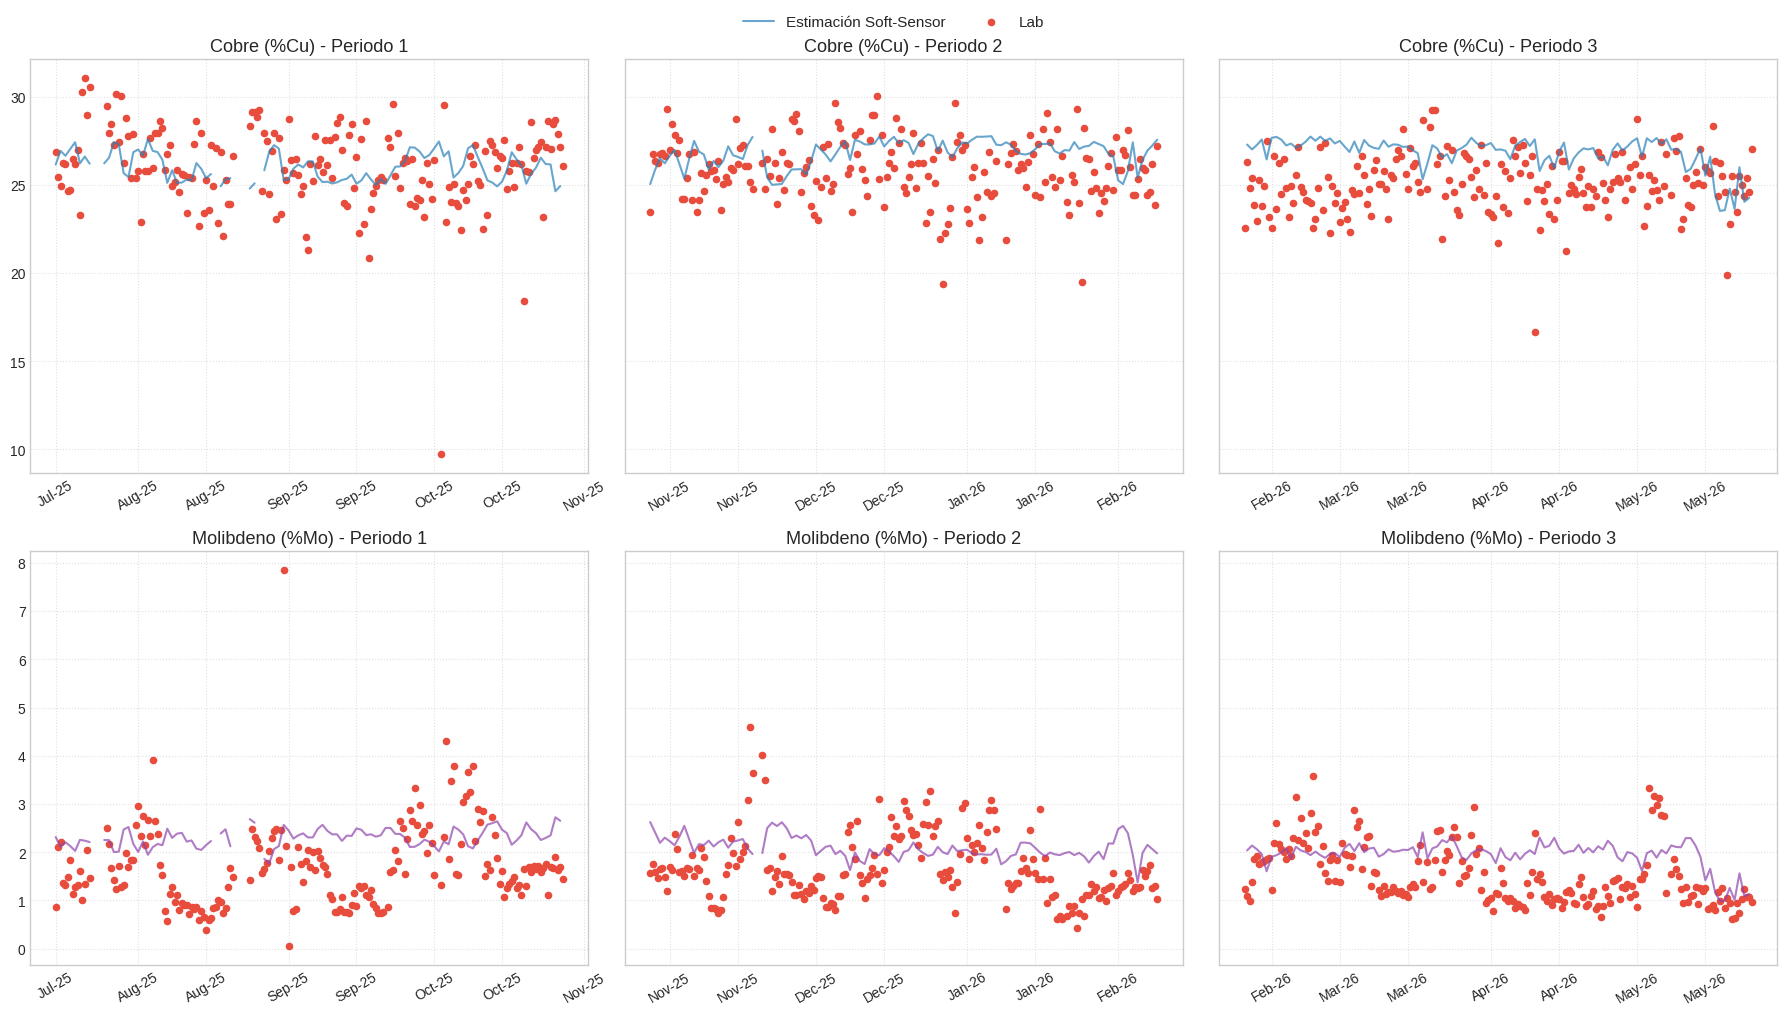

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Carga de datos
df_pred = pd.read_csv('data/final/soft_sensor_continuous_predictions.csv')
df_pred['timestamp'] = pd.to_datetime(df_pred['timestamp'])
df_lab = pd.read_csv('data/processed/assays_clean_no_duplicates.csv')
df_lab['timestamp'] = pd.to_datetime(df_lab['timestamp'])

# Remuestreo diario para suavizar la línea continua
df_pred_daily = df_pred.set_index('timestamp').resample('D').mean().reset_index()

# 2. Definición de periodos (Dividir el tiempo total en tres tercios)
total_start = df_pred['timestamp'].min()
total_end = df_pred['timestamp'].max()
period_length = (total_end - total_start) / 3

periods = [
    (total_start, total_start + period_length),
    (total_start + period_length, total_start + 2 * period_length),
    (total_start + 2 * period_length, total_end)
]

# 3. Configuración de figuras (2 elementos x 3 periodos = 6 subplots)
elements = [('pCu', 'pCu_Est', 'Cobre (%Cu)', '#2980b9'), 
            ('pMo', 'pMo_Est', 'Molibdeno (%Mo)', '#8e44ad')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')

for row, (col_lab, col_est, title, color) in enumerate(elements):
    for col, (start, end) in enumerate(periods):
        ax = axes[row, col]
        
        # Filtrar datos por periodo
        df_pred_sub = df_pred_daily[(df_pred_daily['timestamp'] >= start) & (df_pred_daily['timestamp'] <= end)]
        df_lab_sub = df_lab[(df_lab['timestamp'] >= start) & (df_lab['timestamp'] <= end)]
        
        # Plotear
        ax.plot(df_pred_sub['timestamp'], df_pred_sub[col_est], color=color, alpha=0.7, label='Estimación Soft-Sensor')
        ax.scatter(df_lab_sub['timestamp'], df_lab_sub[col_lab], color='#e74c3c', s=20, label='Lab')
        
        ax.set_title(f"{title} - Periodo {col + 1}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        plt.setp(ax.get_xticklabels(), rotation=30)
        ax.grid(True, linestyle=':', alpha=0.6)

# Ajustes finales
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig('figura_comparativa_anual_detallada.png', dpi=300)
plt.show()